# M5 data inspection & exploration

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
calendar = pd.read_csv('../data/raw/m5/calendar.csv')
price = pd.read_csv('../data/raw/m5/sell_prices.csv')
sales = pd.read_csv('../data/raw/m5/sales_train_validation.csv')

In [24]:
calendar.info()

<class 'pandas.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   date          1969 non-null   str  
 1   wm_yr_wk      1969 non-null   int64
 2   weekday       1969 non-null   str  
 3   wday          1969 non-null   int64
 4   month         1969 non-null   int64
 5   year          1969 non-null   int64
 6   d             1969 non-null   str  
 7   event_name_1  162 non-null    str  
 8   event_type_1  162 non-null    str  
 9   event_name_2  5 non-null      str  
 10  event_type_2  5 non-null      str  
 11  snap_CA       1969 non-null   int64
 12  snap_TX       1969 non-null   int64
 13  snap_WI       1969 non-null   int64
dtypes: int64(7), str(7)
memory usage: 215.5 KB


In [25]:
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [26]:
price.info()

<class 'pandas.DataFrame'>
RangeIndex: 6841121 entries, 0 to 6841120
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   store_id    str    
 1   item_id     str    
 2   wm_yr_wk    int64  
 3   sell_price  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 208.8 MB


In [27]:
price.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [28]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1919 entries, id to d_1913
dtypes: int64(1913), str(6)
memory usage: 446.4 MB


In [29]:
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [30]:
def inspect_dataframe(df, name):
    print("=" * 80)
    print(name)
    print("=" * 80)
    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())
    print("\nDtypes:")
    print(df.dtypes)
    print("\nMissing values:")
    print(df.isna().sum().sort_values(ascending=False).head(20))
    print("\nDuplicates:", df.duplicated().sum())

In [31]:
inspect_dataframe(calendar, "Calendar")
inspect_dataframe(sales, "Sales Validation")
inspect_dataframe(price, "Sell Prices")

Calendar
Shape: (1969, 14)

Columns:
['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'd', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI']

Dtypes:
date              str
wm_yr_wk        int64
weekday           str
wday            int64
month           int64
year            int64
d                 str
event_name_1      str
event_type_1      str
event_name_2      str
event_type_2      str
snap_CA         int64
snap_TX         int64
snap_WI         int64
dtype: object

Missing values:
event_type_2    1964
event_name_2    1964
event_name_1    1807
event_type_1    1807
date               0
wm_yr_wk           0
year               0
month              0
wday               0
weekday            0
d                  0
snap_CA            0
snap_TX            0
snap_WI            0
dtype: int64

Duplicates: 0
Sales Validation
Shape: (30490, 1919)

Columns:
['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2', 'd_3', 'd

In [32]:
hierarchy_columns = [
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id"
]

for col in hierarchy_columns:
    print(f"\n{col}")
    print("Unique:", sales[col].nunique())
    print(sales[col].unique()[:20])


item_id
Unique: 3049
<StringArray>
['HOBBIES_1_001', 'HOBBIES_1_002', 'HOBBIES_1_003', 'HOBBIES_1_004',
 'HOBBIES_1_005', 'HOBBIES_1_006', 'HOBBIES_1_007', 'HOBBIES_1_008',
 'HOBBIES_1_009', 'HOBBIES_1_010', 'HOBBIES_1_011', 'HOBBIES_1_012',
 'HOBBIES_1_013', 'HOBBIES_1_014', 'HOBBIES_1_015', 'HOBBIES_1_016',
 'HOBBIES_1_017', 'HOBBIES_1_018', 'HOBBIES_1_019', 'HOBBIES_1_020']
Length: 20, dtype: str

dept_id
Unique: 7
<StringArray>
[  'HOBBIES_1',   'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2',     'FOODS_1',
     'FOODS_2',     'FOODS_3']
Length: 7, dtype: str

cat_id
Unique: 3
<StringArray>
['HOBBIES', 'HOUSEHOLD', 'FOODS']
Length: 3, dtype: str

store_id
Unique: 10
<StringArray>
['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2',
 'WI_3']
Length: 10, dtype: str

state_id
Unique: 3
<StringArray>
['CA', 'TX', 'WI']
Length: 3, dtype: str


In [33]:
ID_COLUMNS = [
    "id",
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id"
]

DAY_COLUMNS = [
    col for col in sales.columns
    if col.startswith("d_")
]

print("Number of daily columns:", len(DAY_COLUMNS))
print("First:", DAY_COLUMNS[:5])
print("Last:", DAY_COLUMNS[-5:])

Number of daily columns: 1913
First: ['d_1', 'd_2', 'd_3', 'd_4', 'd_5']
Last: ['d_1909', 'd_1910', 'd_1911', 'd_1912', 'd_1913']


In [34]:
calendar["date"] = pd.to_datetime(calendar["date"])

In [35]:
print("Calendar start:", calendar["date"].min())
print("Calendar end:", calendar["date"].max())
print("Number of dates:", calendar["date"].nunique())

Calendar start: 2011-01-29 00:00:00
Calendar end: 2016-06-19 00:00:00
Number of dates: 1969


In [36]:
date_diff = calendar["date"].sort_values().diff().dt.days

date_diff.value_counts()

date
1.0    1968
Name: count, dtype: int64

In [ ]:
event_columns = ["event_name_1", "event_type_1", "event_name_2", "event_type_2"]

for col in event_columns:
    print(f"\n{col}:")
    print(calendar[col].value_counts(dropna=False).head(20))


event_name_1:
event_name_1
NaN                1807
SuperBowl             6
ValentinesDay         6
PresidentsDay         6
LentStart             6
LentWeek2             6
StPatricksDay         6
Purim End             6
Pesach End            6
Mother's day          6
MemorialDay           6
NBAFinalsStart        6
NBAFinalsEnd          6
Ramadan starts        6
OrthodoxEaster        5
Cinco De Mayo         5
IndependenceDay       5
Eid al-Fitr           5
LaborDay              5
ColumbusDay           5
Name: count, dtype: int64

event_type_1:
event_type_1
NaN          1807
Religious      55
National       52
Cultural       37
Sporting       18
Name: count, dtype: int64

event_name_2:
event_name_2
NaN               1964
Father's day         2
Easter               1
Cinco De Mayo        1
OrthodoxEaster       1
Name: count, dtype: int64

event_type_2:
event_type_2
NaN          1964
Cultural        4
Religious       1
Name: count, dtype: int64


In [ ]:
snap_columns = ["snap_CA", "snap_TX", "snap_WI"]

calendar[snap_columns].value_counts()

snap_CA  snap_TX  snap_WI
0        0        0          994
1        1        1          260
0        1        1          195
1        1        0          130
         0        1          130
                  0          130
0        1        0           65
         0        1           65
Name: count, dtype: int64

In [39]:
sales[DAY_COLUMNS].describe()

,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
count,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,...,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000
mean,1.070220,1.041292,0.780026,0.833454,0.627944,0.958052,0.918662,1.244080,1.073663,0.838701,...,1.370581,1.586159,1.693670,1.248245,1.232207,1.159167,1.149000,1.328862,1.605838,1.633158
std,5.126689,5.365468,3.667454,4.415141,3.379344,4.785947,5.059495,6.617729,5.917204,4.206199,...,3.740017,4.097191,4.359809,3.276925,3.125471,2.876026,2.950364,3.358012,4.089422,3.812248
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000
max,360.000000,436.000000,207.000000,323.000000,296.000000,314.000000,316.000000,370.000000,385.000000,353.000000,...,129.000000,160.000000,204.000000,98.000000,100.000000,88.000000,77.000000,141.000000,171.000000,130.000000


In [40]:
sales_values = sales[DAY_COLUMNS]

print("Minimum:", sales_values.min().min())
print("Maximum:", sales_values.max().max())
print("Negative values:", (sales_values < 0).sum().sum())
print("Missing values:", sales_values.isna().sum().sum())

Minimum: 0
Maximum: 763
Negative values: 0
Missing values: 0


In [41]:
zero_ratio = (
    sales_values == 0
).mean().mean()

print(f"Overall zero-demand ratio: {zero_ratio:.2%}")

Overall zero-demand ratio: 68.20%


In [42]:
product_zero_ratio = (
    sales
    .set_index("item_id")[DAY_COLUMNS]
    .eq(0)
    .mean(axis=1)
    .groupby(level=0)
    .mean()
)

In [43]:
product_zero_ratio.describe()

count    3049.000000
mean        0.681963
std         0.201692
min         0.004600
25%         0.553163
50%         0.720805
75%         0.849712
max         0.974543
dtype: float64

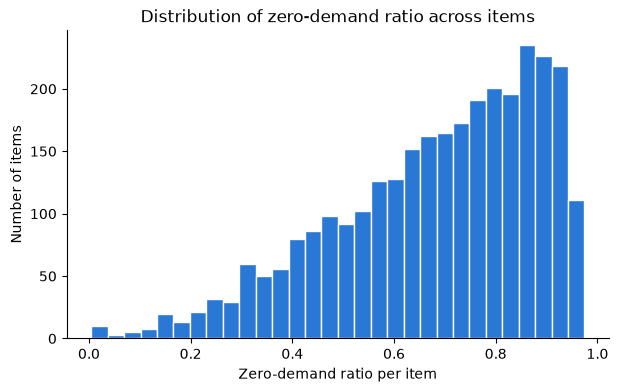

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(product_zero_ratio, bins=30)
ax.set_xlabel("Zero-demand ratio per item")
ax.set_ylabel("Number of items")
ax.set_title("Distribution of zero-demand ratio across items")
plt.show()

## Per-item demand intensity

Aggregate daily sales to item level (summed across all 10 stores) to characterize how much
volume each product represents nationally, and how intermittent its demand is.

In [47]:
item_daily = sales.groupby("item_id")[DAY_COLUMNS].sum()
item_total_demand = item_daily.sum(axis=1)
item_avg_daily = item_total_demand / len(DAY_COLUMNS)

item_meta = sales.groupby("item_id")[["dept_id", "cat_id"]].first()

item_summary = (
    item_meta
    .join(item_total_demand.rename("total_demand"))
    .join(item_avg_daily.rename("avg_daily"))
    .join(product_zero_ratio.rename("zero_ratio"))
)

item_summary.groupby("cat_id")["total_demand"].describe()

,count,mean,std,min,25%,50%,75%,max
cat_id,,,,,,,,
FOODS,1437.0,31377.828114,59520.159093,823.0,7358.0,15004.0,29802.0,1002529.0
HOBBIES,565.0,10840.353982,16919.722104,660.0,2483.0,4829.0,10994.0,122565.0
HOUSEHOLD,1047.0,13830.630372,20836.682747,568.0,3486.0,7247.0,14654.0,171275.0


In [48]:
# Volume tiers by tercile of total demand, used later to pick a high/medium/low mix of products
low_cut, high_cut = item_summary["total_demand"].quantile([0.33, 0.66])


def volume_tier(total_demand):
    if total_demand >= high_cut:
        return "high"
    if total_demand >= low_cut:
        return "medium"
    return "low"


item_summary["volume_tier"] = item_summary["total_demand"].apply(volume_tier)
item_summary.groupby(["cat_id", "volume_tier"]).size().unstack(fill_value=0)

volume_tier,high,low,medium
cat_id,,,
FOODS,698,257,482
HOBBIES,88,310,167
HOUSEHOLD,251,439,357


## Seasonality (weekly and monthly)

Sum demand across all items for each day, then join the calendar to look at weekday and
month effects at the dataset level.

In [49]:
daily_total = sales_values.sum(axis=0)
daily_total.index = DAY_COLUMNS

daily_demand = calendar.set_index("d").loc[DAY_COLUMNS, ["date", "weekday", "month"]].copy()
daily_demand["demand"] = daily_total.values
daily_demand.head()

,date,weekday,month,demand
d,,,,
d_1,2011-01-29,Saturday,1,32631
d_2,2011-01-30,Sunday,1,31749
d_3,2011-01-31,Monday,1,23783
d_4,2011-02-01,Tuesday,2,25412
d_5,2011-02-02,Wednesday,2,19146


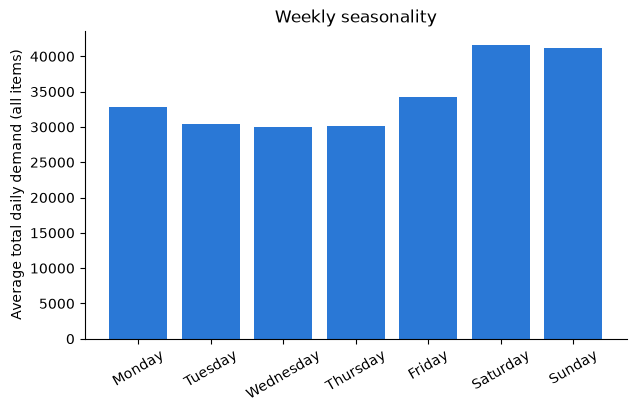

In [ ]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_avg = daily_demand.groupby("weekday")["demand"].mean().reindex(weekday_order)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(weekday_avg.index, weekday_avg.values)
ax.set_ylabel("Average total daily demand (all items)")
ax.set_title("Weekly seasonality")
plt.xticks(rotation=30)
plt.show()

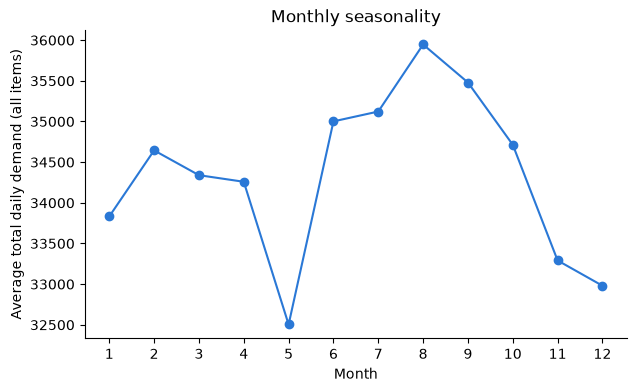

In [ ]:
month_avg = daily_demand.groupby("month")["demand"].mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(month_avg.index, month_avg.values)
ax.set_xticks(range(1, 13))
ax.set_xlabel("Month")
ax.set_ylabel("Average total daily demand (all items)")
ax.set_title("Monthly seasonality")
plt.show()

## Price variation

`sell_prices.csv` is at (store, item, week) granularity. Look at how much each item's price varies across stores and weeks, high variation matters later when we set a single `selling_price` per product in the manufacturing model.

In [52]:
item_price_stats = price.groupby("item_id")["sell_price"].agg(["mean", "std", "min", "max"])
item_price_stats["cv"] = item_price_stats["std"] / item_price_stats["mean"]
item_price_stats["cv"].describe()

count    3049.000000
mean        0.042005
std         0.037010
min         0.000000
25%         0.016249
50%         0.036115
75%         0.058933
max         0.586982
Name: cv, dtype: float64

## Summary of findings

- **Hierarchy**: 3049 items, 7 departments, 3 categories (FOODS, HOUSEHOLD, HOBBIES), 10 stores across CA/TX/WI. Calendar spans 2011-01-29 to 2016-06-19 with no gaps (1969 consecutive days).
- **Sparsity**: demand is highly intermittent, 68% of all (item, store, day) cells are zero, and the per-item zero-ratio spans from near-continuous sellers to items that rarely sell at any single store. This is expected for a retail panel and is one reason we aggregate to national-item level (sum across stores) for the manufacturing scenario, which smooths out store-level intermittency.
- **Volume intensity**: total demand per item is extremely right-skewed within every category, a small number of items dominate volume (FOODS especially). Tercile-based `volume_tier` (high/medium/low) gives a workable way to pick a realistic mix of fast- and slow-movers.
- **Category mix**: FOODS is the largest category by item count and by volume, HOUSEHOLD second, HOBBIES smallest, worth reflecting in the 10-product selection rather than picking an even split.
- **Seasonality**: weekend days (Saturday/Sunday) show visibly higher average demand than weekdays; monthly averages show a mild seasonal pattern (e.g. dip in the deepest winter months) rather than a strong single peak.
- **Price variation**: `sell_prices` varies by store and week even for the same item (coefficient of variation typically in the few-percent to ~20% range), so a single representative selling_price per product in `products.csv` will be a simplification we should note explicitly as an industrial assumption.